# PSY392CPAI Project Analysis (v2)
## Vision-Based RL: Reward, Transition, and Observation Perturbations

Three RL agents compared on an 8×8 gridworld with CNN-encoded observations:
- **PPO** — on-policy actor–critic baseline (no structured prior).
- **SR** — deep successor features: Q(s,a)=⟨ψ(s,a), w⟩, per Dayan (1993) / Russek et al. (2017).
- **Replay** — DQN + experience replay; replay buffer provides Dyna-style planning (Sutton 1990).

### Five conditions
| Condition | Analog | Reference |
|---|---|---|
| `stable` | Baseline | — |
| `reward_change` | Reward revaluation | Momennejad et al. (2017) |
| `transition_change` | Transition revaluation | Momennejad et al. (2017) |
| `obs_visual` | Rate remapping | Sanders, Wilson & Gershman (2020) |
| `obs_remap` | Global remapping | Sanders et al. (2020) |

### Evaluation
1. **Zero-shot** — frozen weights from `stable` training, evaluated on all 5 conditions.
2. **Few-shot adaptation** — continue training on each changed condition; log return and periodic greedy success rate.

Three seeds (0, 1, 2) per agent; curves show mean ± std. One targeted ablation: deep-SR without φ-normalization (Lehnert et al. 2024).

In [1]:
import sys, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

project_dir = Path('..').resolve()
sys.path.insert(0, str(project_dir))

results_dir = project_dir / 'results'
csv_dir     = results_dir / 'csv'
fig_dir     = results_dir / 'figures'
fig_dir.mkdir(exist_ok=True)

SEEDS = [0, 1, 2]
AGENTS = ['PPO', 'SR', 'Replay']
AGENT_PREFIX = {'PPO': 'ppo', 'SR': 'sr', 'Replay': 'replay'}
COLORS = {'PPO': '#E15759', 'SR': '#4E79A7', 'Replay': '#59A14F'}

ALL_CONDS = ['stable', 'reward_change', 'transition_change', 'obs_visual', 'obs_remap']
CHANGED   = ['reward_change', 'transition_change', 'obs_visual', 'obs_remap']
COND_LABEL = {
    'stable':            'Stable',
    'reward_change':     'Reward Change',
    'transition_change': 'Transition Change',
    'obs_visual':        'Obs: Visual Distractors',
    'obs_remap':         'Obs: Channel Remap',
}
COND_COLOR = {
    'stable':            '#555555',
    'reward_change':     '#E15759',
    'transition_change': '#59A14F',
    'obs_visual':        '#F28E2B',
    'obs_remap':         '#AF7AA1',
}

print('Results directory:', results_dir)
csv_files = sorted([f.name for f in csv_dir.glob('*.csv')])
print(f'CSV files ({len(csv_files)}):')
for f in csv_files:
    print('  ', f)

Results directory: D:\MS 2024-25\Purdue\ACS - Program - Autonomy\Courses\Semesters\Spring'26\PSY392CPAI\repo\psy392cpai\project\results
CSV files (94):
   ppo_seed0_adapt_obs_remap_full.csv
   ppo_seed0_adapt_obs_visual_full.csv
   ppo_seed0_adapt_reward_change_full.csv
   ppo_seed0_adapt_transition_change_full.csv
   ppo_seed0_eval_obs_remap.csv
   ppo_seed0_eval_obs_visual.csv
   ppo_seed0_eval_reward_change.csv
   ppo_seed0_eval_stable.csv
   ppo_seed0_eval_transition_change.csv
   ppo_seed0_train.csv
   ppo_seed1_adapt_obs_remap_full.csv
   ppo_seed1_adapt_obs_visual_full.csv
   ppo_seed1_adapt_reward_change_full.csv
   ppo_seed1_adapt_transition_change_full.csv
   ppo_seed1_eval_obs_remap.csv
   ppo_seed1_eval_obs_visual.csv
   ppo_seed1_eval_reward_change.csv
   ppo_seed1_eval_stable.csv
   ppo_seed1_eval_transition_change.csv
   ppo_seed1_train.csv
   ppo_seed2_adapt_obs_remap_full.csv
   ppo_seed2_adapt_obs_visual_full.csv
   ppo_seed2_adapt_reward_change_full.csv
   ppo_seed2_

## 1. Environment Visualization (five conditions)

`obs_visual` adds low-intensity distractor pixels to channel 0 (agent-channel view is perturbed without changing underlying state identity); `obs_remap` permutes the three observation channels so that the mapping from pixels to semantics is broken.

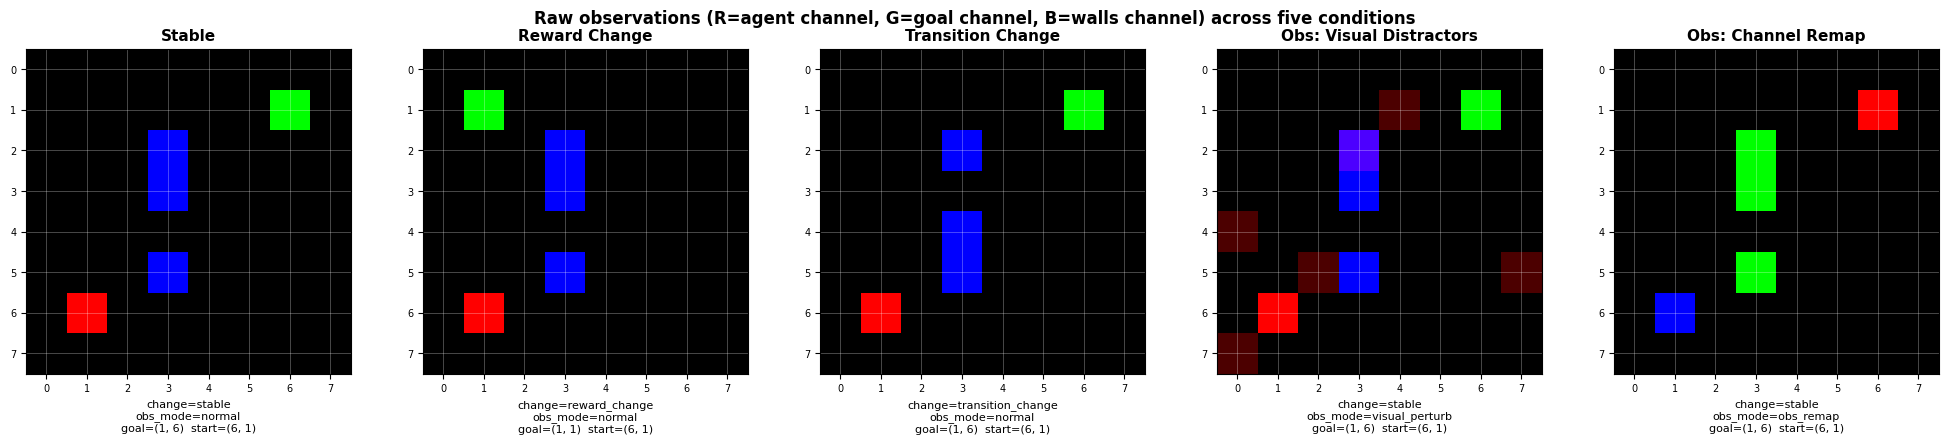

In [2]:
from src.envs.gridworld import GridWorldEnv
from src.common.adaptation import ALL_CONDITIONS, make_env

fig, axes = plt.subplots(1, 5, figsize=(20, 4.2))
for ax, cond in zip(axes, ALL_CONDITIONS):
    env = make_env(cond, seed=0)
    td  = env.reset()
    obs = td['observation'].numpy()  # shape (3, 8, 8)

    rgb = np.stack([obs[0], obs[1], obs[2]], axis=-1)
    rgb = rgb / max(rgb.max(), 1e-6)

    ax.imshow(rgb, origin='upper', interpolation='nearest')
    ax.set_title(COND_LABEL[cond.name], fontsize=11, fontweight='bold')
    ax.set_xticks(range(8)); ax.set_yticks(range(8))
    ax.tick_params(labelsize=7)
    ax.grid(True, color='white', linewidth=0.4, alpha=0.5)
    ax.set_xlabel(
        f'change={cond.change_mode}\n'
        f'obs_mode={cond.observation_mode}\n'
        f'goal={env.goal_pos}  start={env.agent_pos}',
        fontsize=8)

fig.suptitle('Raw observations (R=agent channel, G=goal channel, B=walls channel) across five conditions',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(fig_dir / 'env_conditions.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Stable-phase training curves (mean ± std across 3 seeds)

PPO is frame-based (50k frames over 512-frame batches); SR and Replay are episode-based.

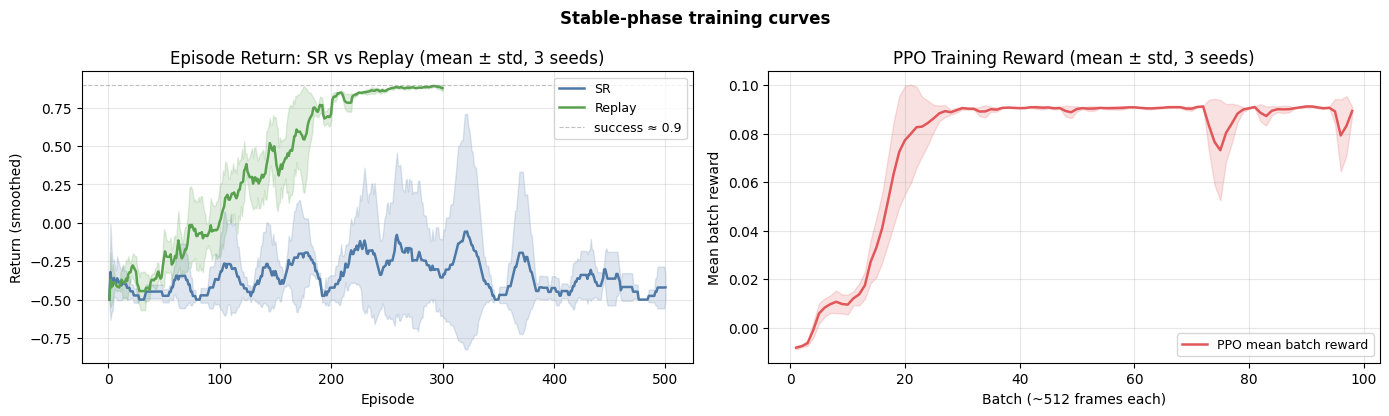

In [3]:
def smooth(s, w=15):
    return pd.Series(s).rolling(w, min_periods=1).mean().values

def load_train(agent):
    frames = []
    for s in SEEDS:
        p = csv_dir / f'{AGENT_PREFIX[agent]}_seed{s}_train.csv'
        if p.exists():
            df = pd.read_csv(p); df['seed'] = s; frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else None

def mean_std_by(df, x_col, y_col, w=15):
    out = []
    for s, g in df.groupby('seed'):
        g = g.sort_values(x_col)
        out.append(pd.DataFrame({x_col: g[x_col].values, 'y': smooth(g[y_col].values, w), 'seed': s}))
    D = pd.concat(out)
    agg = D.groupby(x_col)['y'].agg(['mean', 'std']).reset_index()
    return agg

ppo_tr    = load_train('PPO')
sr_tr     = load_train('SR')
replay_tr = load_train('Replay')

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))

ax = axes[0]
if sr_tr is not None:
    agg = mean_std_by(sr_tr, 'episode', 'episode_return')
    ax.plot(agg['episode'], agg['mean'], color=COLORS['SR'], label='SR', linewidth=1.8)
    ax.fill_between(agg['episode'], agg['mean']-agg['std'], agg['mean']+agg['std'],
                    color=COLORS['SR'], alpha=0.18)
if replay_tr is not None:
    agg = mean_std_by(replay_tr, 'episode', 'episode_return')
    ax.plot(agg['episode'], agg['mean'], color=COLORS['Replay'], label='Replay', linewidth=1.8)
    ax.fill_between(agg['episode'], agg['mean']-agg['std'], agg['mean']+agg['std'],
                    color=COLORS['Replay'], alpha=0.18)
ax.axhline(0.9, color='grey', linestyle='--', linewidth=0.8, alpha=0.5, label='success ≈ 0.9')
ax.set_xlabel('Episode'); ax.set_ylabel('Return (smoothed)')
ax.set_title('Episode Return: SR vs Replay (mean ± std, 3 seeds)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
if ppo_tr is not None:
    ppo_tr['frames_k'] = ppo_tr['collected_frames'] / 1000
    agg = mean_std_by(ppo_tr, 'batch_idx', 'mean_batch_reward', w=5)
    ax.plot(agg['batch_idx'], agg['mean'], color=COLORS['PPO'], label='PPO mean batch reward', linewidth=1.8)
    ax.fill_between(agg['batch_idx'], agg['mean']-agg['std'], agg['mean']+agg['std'],
                    color=COLORS['PPO'], alpha=0.18)
ax.set_xlabel('Batch (~512 frames each)'); ax.set_ylabel('Mean batch reward')
ax.set_title('PPO Training Reward (mean ± std, 3 seeds)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

fig.suptitle('Stable-phase training curves', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(fig_dir / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Zero-shot evaluation on all five conditions (stable-trained agents, frozen weights)

Each point is mean of 20 greedy episodes per checkpoint. Shaded region is ±1 std across seeds.

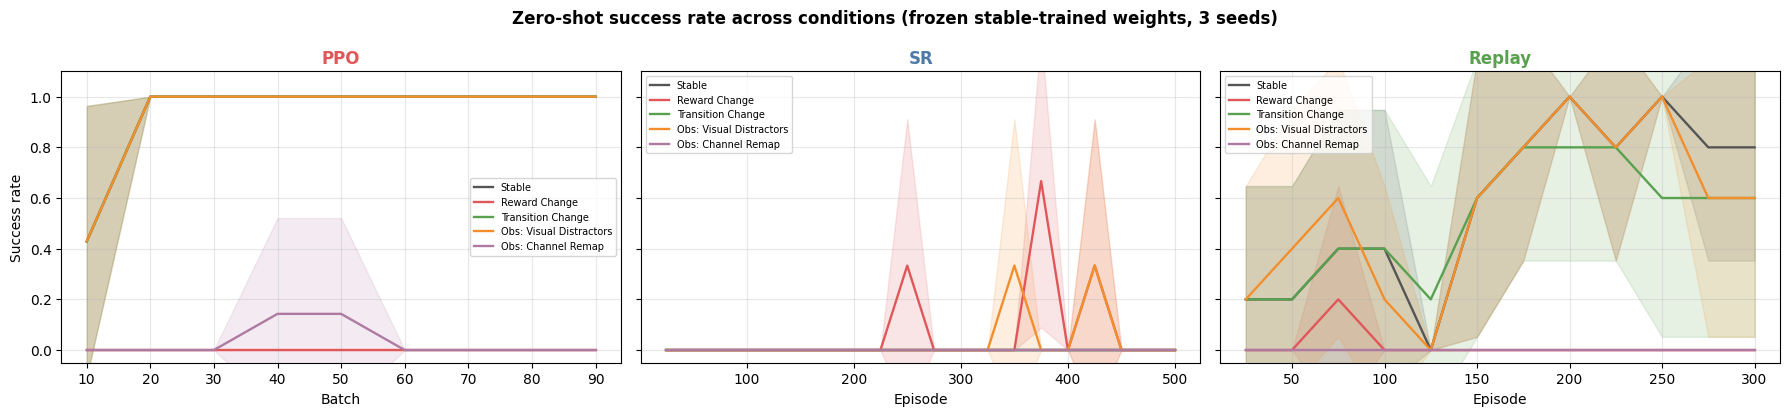

In [4]:
def load_eval(agent):
    frames = []
    for s in SEEDS:
        for cond in ALL_CONDS:
            p = csv_dir / f'{AGENT_PREFIX[agent]}_seed{s}_eval_{cond}.csv'
            if p.exists():
                df = pd.read_csv(p); df['seed'] = s; frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else None

ppo_ev    = load_eval('PPO')
sr_ev     = load_eval('SR')
replay_ev = load_eval('Replay')

fig, axes = plt.subplots(1, 3, figsize=(18, 4.2), sharey=True)
agent_evs = {'PPO': ppo_ev, 'SR': sr_ev, 'Replay': replay_ev}
for ax, (name, df) in zip(axes, agent_evs.items()):
    if df is None:
        ax.text(0.5, 0.5, 'No data yet', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(name); continue
    x_col = 'episode' if 'episode' in df.columns else 'batch_idx'
    for cond in ALL_CONDS:
        sub = df[df['condition'] == cond]
        if sub.empty: continue
        agg = sub.groupby(x_col)['success_rate'].agg(['mean', 'std']).reset_index()
        ax.plot(agg[x_col], agg['mean'], color=COND_COLOR[cond], label=COND_LABEL[cond], linewidth=1.7)
        ax.fill_between(agg[x_col], agg['mean']-agg['std'].fillna(0), agg['mean']+agg['std'].fillna(0),
                        color=COND_COLOR[cond], alpha=0.15)
    ax.set_title(name, color=COLORS[name], fontweight='bold')
    ax.set_xlabel('Episode' if x_col == 'episode' else 'Batch')
    ax.set_ylim(-0.05, 1.1)
    ax.grid(True, alpha=0.3)
    if ax is axes[0]: ax.set_ylabel('Success rate')
    ax.legend(fontsize=7, loc='best')

fig.suptitle('Zero-shot success rate across conditions (frozen stable-trained weights, 3 seeds)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(fig_dir / 'zero_shot_eval.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Few-shot adaptation curves (primary test of H1–H5)

For each agent and each of the 4 changed conditions, we continue training from the stable checkpoint and log return/success every few episodes (SR/Replay) or batches (PPO).
- **SR + reward_change**: two variants — `wonly` (Momennejad-style reward-weights-only) and `full` (all parameters unfrozen).
- All other (agent, condition) pairs: `full` only.

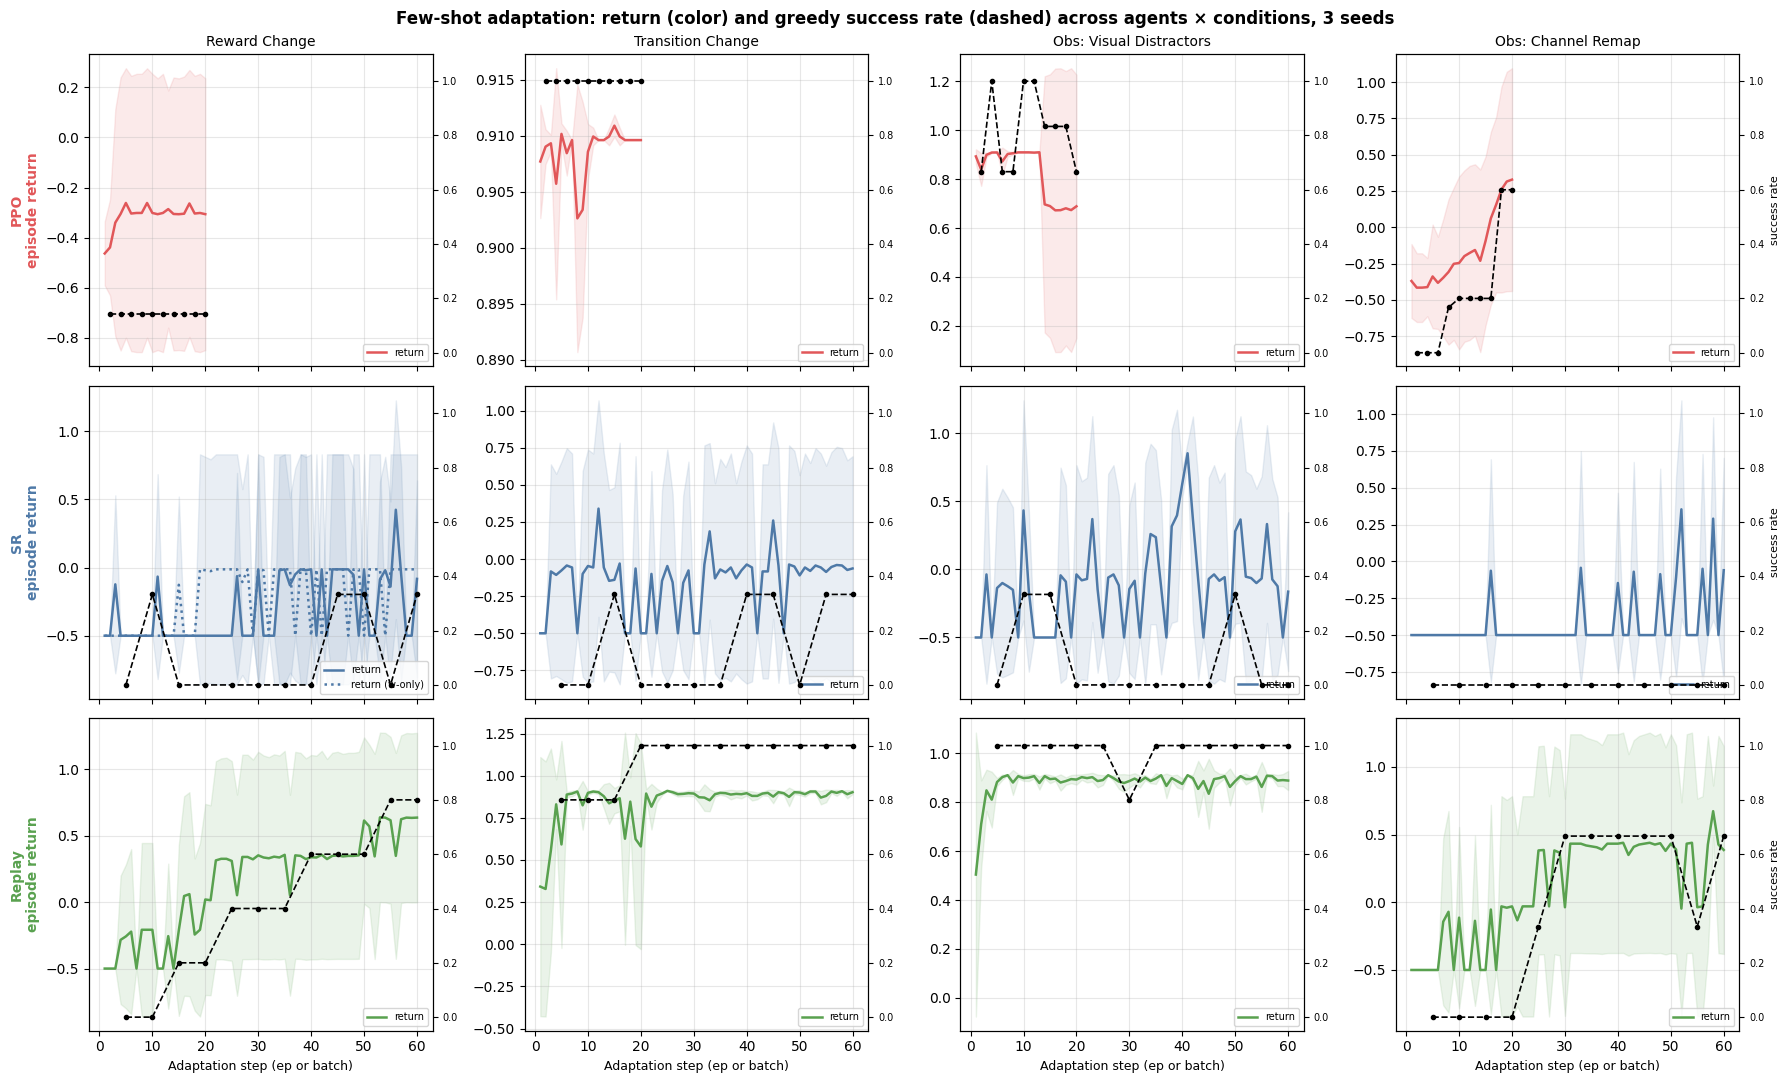

In [5]:
def load_adapt(agent):
    frames = []
    for s in SEEDS:
        for cond in CHANGED:
            for variant in ['full', 'wonly']:
                p = csv_dir / f'{AGENT_PREFIX[agent]}_seed{s}_adapt_{cond}_{variant}.csv'
                if p.exists():
                    df = pd.read_csv(p); df['seed'] = s; frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else None

ppo_ad    = load_adapt('PPO')
sr_ad     = load_adapt('SR')
replay_ad = load_adapt('Replay')

fig, axes = plt.subplots(3, 4, figsize=(18, 11), sharex='col')
for row, (name, df) in enumerate([('PPO', ppo_ad), ('SR', sr_ad), ('Replay', replay_ad)]):
    for col, cond in enumerate(CHANGED):
        ax = axes[row, col]
        if df is None or df[df['condition'] == cond].empty:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes, fontsize=9)
        else:
            for variant, (ls, lab_suffix) in zip(['full', 'wonly'], [('-', ''), (':', ' (w-only)')]):
                sub = df[(df['condition'] == cond) & (df['variant'] == variant)]
                if sub.empty: continue
                agg = sub.groupby('step')['episode_return'].agg(['mean', 'std']).reset_index()
                ax.plot(agg['step'], agg['mean'], color=COLORS[name], linestyle=ls, linewidth=1.8,
                        label=f'return{lab_suffix}')
                ax.fill_between(agg['step'], agg['mean']-agg['std'].fillna(0), agg['mean']+agg['std'].fillna(0),
                                color=COLORS[name], alpha=0.12)
                sub_eval = sub[sub['eval_success_rate'].notna()]
                if not sub_eval.empty and variant == 'full':
                    agg2 = sub_eval.groupby('step')['eval_success_rate'].agg(['mean', 'std']).reset_index()
                    axb = ax.twinx()
                    axb.plot(agg2['step'], agg2['mean'], color='black', linestyle='--',
                             linewidth=1.2, marker='o', markersize=3, label='greedy success')
                    axb.set_ylim(-0.05, 1.1)
                    axb.tick_params(axis='y', labelsize=7)
                    if col == 3: axb.set_ylabel('success rate', fontsize=8)
        if row == 0: ax.set_title(COND_LABEL[cond], fontsize=10)
        if col == 0: ax.set_ylabel(f'{name}\nepisode return', fontsize=10, fontweight='bold', color=COLORS[name])
        if row == 2: ax.set_xlabel('Adaptation step (ep or batch)', fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7, loc='lower right')

fig.suptitle('Few-shot adaptation: return (color) and greedy success rate (dashed) across agents × conditions, 3 seeds',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.subplots_adjust(top=0.94)
plt.savefig(fig_dir / 'adaptation_grid.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Cross-agent adaptation comparison at fixed checkpoints

For each condition, compare mean eval success rate across agents at early, mid, and late adaptation steps. Tests H1 (SR wins on reward_change), H2 (Replay wins on transition_change), H4 (all recover on obs_visual), H5 (slow recovery on obs_remap).

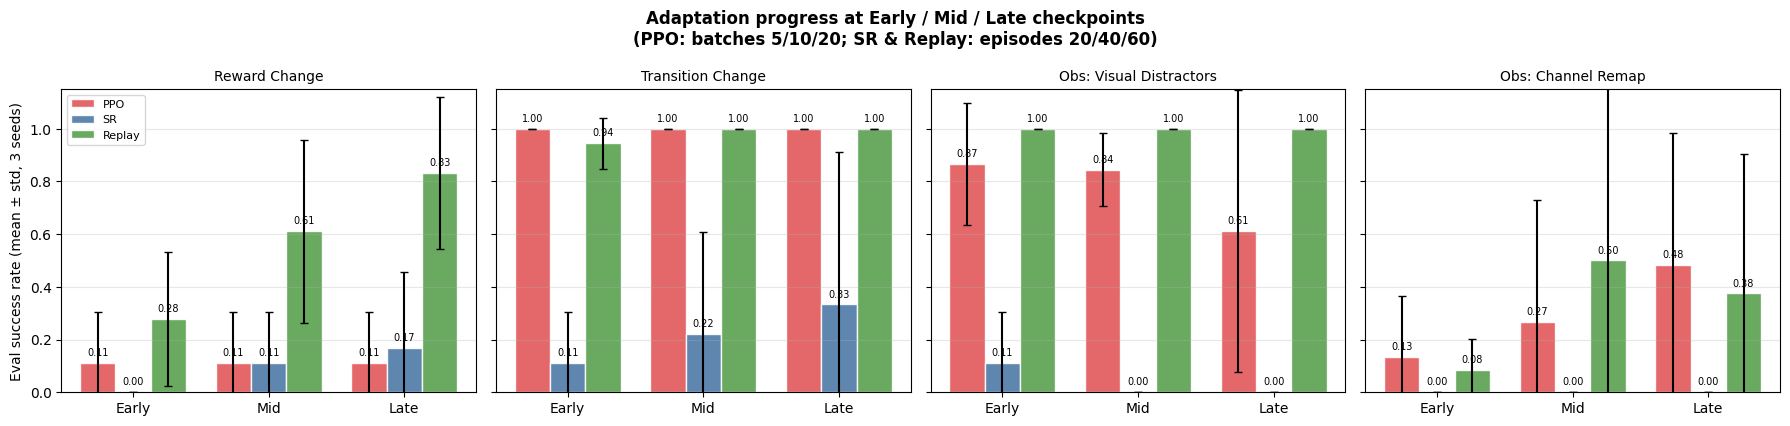

In [6]:
def eval_at_step(df, cond, target_step, variant='full', tol=5):
    if df is None: return (np.nan, np.nan)
    sub = df[(df['condition'] == cond) & (df['variant'] == variant) &
             df['eval_success_rate'].notna()]
    if sub.empty: return (np.nan, np.nan)
    sub = sub.assign(dist=(sub['step'] - target_step).abs())
    sub = sub[sub['dist'] <= tol]
    if sub.empty: return (np.nan, np.nan)
    per_seed = sub.groupby('seed')['eval_success_rate'].mean()
    return per_seed.mean(), per_seed.std()

# Per-agent checkpoint schedules (Early / Mid / Late)
CHECKPOINTS = {'PPO': [5, 10, 20], 'SR': [20, 40, 60], 'Replay': [20, 40, 60]}

fig, axes = plt.subplots(1, 4, figsize=(18, 4.3), sharey=True)
for ax, cond in zip(axes, CHANGED):
    x = np.arange(3); width = 0.26
    for i, (name, df) in enumerate([('PPO', ppo_ad), ('SR', sr_ad), ('Replay', replay_ad)]):
        chks = CHECKPOINTS[name]
        means, stds = zip(*[eval_at_step(df, cond, t) for t in chks])
        bars = ax.bar(x + (i-1)*width, means, width=width, yerr=stds,
                       color=COLORS[name], label=name, alpha=0.9, edgecolor='white', capsize=3)
        for b, m in zip(bars, means):
            if not np.isnan(m):
                ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.02, f'{m:.2f}',
                        ha='center', va='bottom', fontsize=7)
    ax.set_xticks(x); ax.set_xticklabels(['Early', 'Mid', 'Late'])
    ax.set_title(COND_LABEL[cond], fontsize=10)
    ax.set_ylim(0, 1.15)
    ax.grid(True, axis='y', alpha=0.3)
    if ax is axes[0]:
        ax.set_ylabel('Eval success rate (mean ± std, 3 seeds)')
        ax.legend(fontsize=8)

fig.suptitle('Adaptation progress at Early / Mid / Late checkpoints\n(PPO: batches 5/10/20; SR & Replay: episodes 20/40/60)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(fig_dir / 'cross_agent_adaptation.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Ablation: SR without φ-normalization (Lehnert et al. 2024)

Removing the L2 normalization of features in `SRNet.encode` should cause the successor-feature fixed point (bounded by 1/(1−γ) only when ‖φ‖ is bounded) to diverge. Loss and ‖φ‖ should grow without bound.

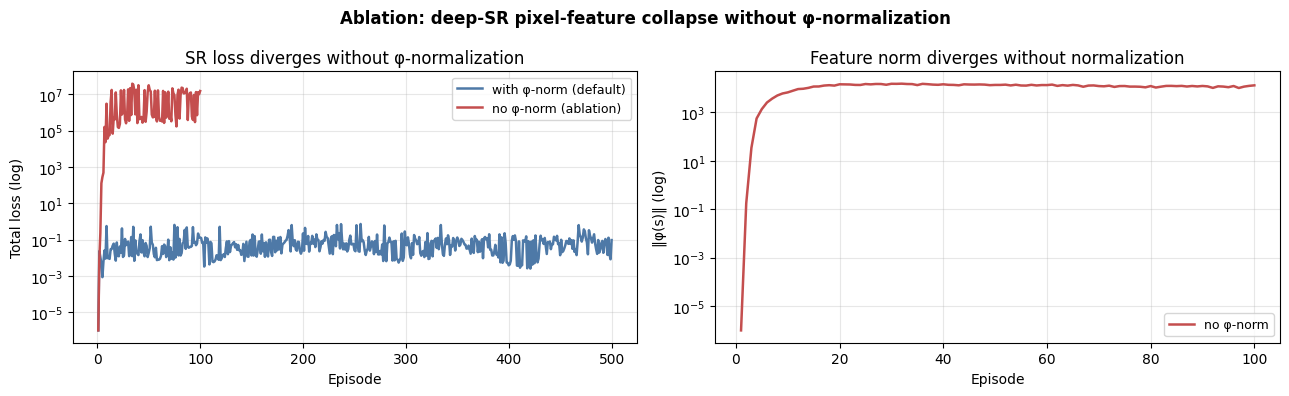

In [7]:
p_norm    = csv_dir / 'sr_seed0_train.csv'
p_no_norm = csv_dir / 'sr_no_norm_seed0_train.csv'

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
if p_norm.exists() and p_no_norm.exists():
    dn = pd.read_csv(p_norm)
    dx = pd.read_csv(p_no_norm)

    ax = axes[0]
    ax.semilogy(dn['episode'], dn['total_loss'].clip(lower=1e-6), color=COLORS['SR'],
                label='with φ-norm (default)', linewidth=1.8)
    ax.semilogy(dx['episode'], dx['total_loss'].clip(lower=1e-6), color='#C44E4E',
                label='no φ-norm (ablation)', linewidth=1.8)
    ax.set_xlabel('Episode'); ax.set_ylabel('Total loss (log)')
    ax.set_title('SR loss diverges without φ-normalization')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3, which='both')

    ax = axes[1]
    if 'phi_norm' in dn.columns:
        ax.semilogy(dn['episode'], dn['phi_norm'].clip(lower=1e-6), color=COLORS['SR'],
                    label='with φ-norm', linewidth=1.8)
    if 'phi_norm' in dx.columns:
        ax.semilogy(dx['episode'], dx['phi_norm'].clip(lower=1e-6), color='#C44E4E',
                    label='no φ-norm', linewidth=1.8)
    ax.set_xlabel('Episode'); ax.set_ylabel('‖φ(s)‖ (log)')
    ax.set_title('Feature norm diverges without normalization')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3, which='both')

    fig.suptitle('Ablation: deep-SR pixel-feature collapse without φ-normalization', fontweight='bold')
    plt.tight_layout()
    plt.savefig(fig_dir / 'ablation_sr_no_norm.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Ablation CSVs not yet available. Expected:', p_norm, p_no_norm)

## 7. Summary statistics (zero-shot vs adapted success rates)

In [8]:
def zs_final(df, cond, last_n=3):
    if df is None: return (np.nan, np.nan)
    sub = df[df['condition'] == cond]
    if sub.empty: return (np.nan, np.nan)
    x_col = 'episode' if 'episode' in sub.columns else 'batch_idx'
    per_seed = sub.groupby('seed').apply(lambda g: g.sort_values(x_col).tail(last_n)['success_rate'].mean())
    return per_seed.mean(), per_seed.std()

def ad_final(df, cond, variant='full', last_n=3):
    if df is None: return (np.nan, np.nan)
    sub = df[(df['condition'] == cond) & (df['variant'] == variant) & df['eval_success_rate'].notna()]
    if sub.empty: return (np.nan, np.nan)
    per_seed = sub.groupby('seed').apply(lambda g: g.sort_values('step').tail(last_n)['eval_success_rate'].mean())
    return per_seed.mean(), per_seed.std()

rows = []
agent_evs = {'PPO': ppo_ev, 'SR': sr_ev, 'Replay': replay_ev}
agent_ads = {'PPO': ppo_ad, 'SR': sr_ad, 'Replay': replay_ad}
for agent in AGENTS:
    for cond in ALL_CONDS:
        zs_m, zs_s = zs_final(agent_evs[agent], cond)
        if cond == 'stable':
            ad_m, ad_s = (np.nan, np.nan)
        else:
            ad_m, ad_s = ad_final(agent_ads[agent], cond, 'full')
        rows.append(dict(
            Agent=agent,
            Condition=COND_LABEL[cond],
            ZeroShot=f'{zs_m:.2f} ± {zs_s:.2f}' if not np.isnan(zs_m) else '—',
            Adapted=f'{ad_m:.2f} ± {ad_s:.2f}' if not np.isnan(ad_m) else '—',
        ))
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))
summary.to_csv(results_dir / 'summary_table.csv', index=False)

 Agent               Condition    ZeroShot     Adapted
   PPO                  Stable 1.00 ± 0.00           —
   PPO           Reward Change 0.00 ± 0.00 0.11 ± 0.19
   PPO       Transition Change 1.00 ± 0.00 1.00 ± 0.00
   PPO Obs: Visual Distractors 1.00 ± 0.00 0.56 ± 0.51
   PPO      Obs: Channel Remap 0.00 ± 0.00 0.56 ± 0.51
    SR                  Stable 0.00 ± 0.00           —
    SR           Reward Change 0.00 ± 0.00 0.22 ± 0.19
    SR       Transition Change 0.00 ± 0.00 0.22 ± 0.38
    SR Obs: Visual Distractors 0.00 ± 0.00 0.11 ± 0.19
    SR      Obs: Channel Remap 0.00 ± 0.00 0.00 ± 0.00
Replay                  Stable 0.89 ± 0.19           —
Replay           Reward Change 0.00 ± 0.00 0.78 ± 0.38
Replay       Transition Change 0.67 ± 0.58 1.00 ± 0.00
Replay Obs: Visual Distractors 0.67 ± 0.33 1.00 ± 0.00
Replay      Obs: Channel Remap 0.00 ± 0.00 0.50 ± 0.71


## 8. Hypothesis readout

| ID | Prediction | Primary test cell |
|----|-----------|-------------------|
| **H1** | SR adapts fastest on `reward_change` | §5 `reward_change` bars; SR > PPO, ideally SR ≥ Replay at Early. |
| **H2** | Replay adapts fastest on `transition_change` | §5 `transition_change` bars; Replay leads. |
| **H3** | Dissociation (H1 ∧ H2) | Cross-plot reading of §5. |
| **H4** | All agents recover on `obs_visual` (state identity preserved) | §5 `obs_visual`: Late bars close to stable; zero-shot drop in §7 → adapted recovery. |
| **H5** | `obs_remap` is hardest; recovery slower than `obs_visual` | §5 `obs_remap` vs `obs_visual` bars; Late `obs_remap` < Late `obs_visual`. |

### Key biological / literature anchors
- **Dayan (1993)** introduced the successor representation as a predictive map; **Russek et al. (2017)** showed it interpolates between MF and MB.
- **Stachenfeld, Botvinick & Gershman (2017)** recast the hippocampus as encoding an SR-like predictive map.
- **Momennejad et al. (2017, *Nat Hum Behav*)** is the direct behavioral template for H1/H2: SR predicts asymmetric revaluation behavior.
- **Barreto et al. (2017)** first scaled SF with deep neural nets to pixel observations.
- **Sanders, Wilson & Gershman (2020, *eLife*)** treats hippocampal remapping as hidden-state inference; the `obs_visual`/`obs_remap` manipulations are computational analogs of rate and global remapping.
- **Lehnert et al. (2024)** documents that deep SF networks without feature normalization collapse — validated here by §6.
- **Sutton (1990)** Dyna framework motivates the replay agent as a planning-via-sampling baseline.
- **Whitehead & Ballard (1992)** foundational perceptual-aliasing reference for why `obs_remap` is hard.